In [ ]:
%pip install numpy pandas matplotlib scikit-learn sklearn-crfsuite tensorflow seqeval joblib streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.0 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=3e57c9937fae79c0acc11c646ab058d983b77761c1a035b25b60e9afdd7f54e1
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
!python nlp_preprocessing_fixed.py


STEP 0 – LOAD & PARSE JSONL DATASET
  Loaded   : 1046 records
  Entities : 19,470 annotations
  Labels   : ['Achievements', 'Certifications', 'College', 'College Name', 'Companies worked at', 'Degree', 'Designation', 'Email Address', 'Graduation Year', 'Links', 'Location', 'Name', 'Projects', 'Relocate To', 'Relocation', 'Skills', 'State', 'Training', 'Years of Experience']

STEP 1 – DATASET EXPLORATION  (4 charts)
  Chart 1 saved → charts/chart1_label_distribution.png
  Chart 2 saved → charts/chart2_text_length_distribution.png
  Chart 3 saved → charts/chart3_avg_entities_per_resume.png
  Chart 4 saved → charts/chart4_top_skills.png

STEP 2 – DEDUPLICATION  (exact + near-duplicate removal, Jaccard ≥ 0.90)
  Records before deduplication : 1046
  Duplicates removed           : 168
  Removed at indices           : [132, 133, 336, 371, 372, 373, 462, 474, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602,

In [ ]:
import json
import joblib
import numpy as np
from pathlib import Path
from collections import Counter

from sklearn.metrics import classification_report
from sklearn_crfsuite import CRF
from sklearn_crfsuite.metrics import flat_classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, TimeDistributed, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


OUTPUT_DIR = Path("output")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

TRAIN_PATH = OUTPUT_DIR / "train.jsonl"
VAL_PATH = OUTPUT_DIR / "val.jsonl"
TEST_PATH = OUTPUT_DIR / "test.jsonl"


# =========================================================
# 1. LOAD BIO DATA
# =========================================================

def load_jsonl_sequences(path):
    sequences = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            item = json.loads(line)

            if isinstance(item, list):
                seq = item

            elif isinstance(item, dict):
                if "sequence" in item:
                    seq = item["sequence"]
                elif "bio_sequence" in item:   # ✅ FIX ADDED
                    seq = item["bio_sequence"]
                elif "tokens" in item and "tags" in item:
                    seq = list(zip(item["tokens"], item["tags"]))
                elif "bio" in item:
                    seq = item["bio"]
                else:
                    raise ValueError(f"Unknown JSONL format in {path}: {item.keys()}")

            fixed = []

            for pair in seq:
                if isinstance(pair, dict):
                    token = pair.get("token") or pair.get("word")
                    tag = pair.get("tag") or pair.get("label")
                else:
                    token, tag = pair[0], pair[1]

                fixed.append((str(token), str(tag)))

            if fixed:
                sequences.append(fixed)

    return sequences


train_seqs = load_jsonl_sequences(TRAIN_PATH)
val_seqs = load_jsonl_sequences(VAL_PATH)
test_seqs = load_jsonl_sequences(TEST_PATH)

print("Train sequences:", len(train_seqs))
print("Validation sequences:", len(val_seqs))
print("Test sequences:", len(test_seqs))


# =========================================================
# 2. FEATURE REPRESENTATION 1 — CRF HANDCRAFTED FEATURES
# =========================================================

def word2features(sent, i):
    word = sent[i][0]

    features = {
        "bias": 1.0,
        "word.lower": word.lower(),
        "word[-3:]": word[-3:],
        "word[-2:]": word[-2:],
        "word[:2]": word[:2],
        "word[:3]": word[:3],
        "word.isupper": word.isupper(),
        "word.istitle": word.istitle(),
        "word.isdigit": word.isdigit(),
        "word.has_digit": any(ch.isdigit() for ch in word),
        "word.has_hyphen": "-" in word,
        "word.length": len(word),
    }

    if i > 0:
        prev_word = sent[i - 1][0]
        features.update({
            "-1:word.lower": prev_word.lower(),
            "-1:word.istitle": prev_word.istitle(),
            "-1:word.isupper": prev_word.isupper(),
        })
    else:
        features["BOS"] = True

    if i < len(sent) - 1:
        next_word = sent[i + 1][0]
        features.update({
            "+1:word.lower": next_word.lower(),
            "+1:word.istitle": next_word.istitle(),
            "+1:word.isupper": next_word.isupper(),
        })
    else:
        features["EOS"] = True

    return features


def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]


def sent2labels(sent):
    return [label for _, label in sent]


X_train_crf = [sent2features(s) for s in train_seqs]
y_train_crf = [sent2labels(s) for s in train_seqs]

X_val_crf = [sent2features(s) for s in val_seqs]
y_val_crf = [sent2labels(s) for s in val_seqs]

X_test_crf = [sent2features(s) for s in test_seqs]
y_test_crf = [sent2labels(s) for s in test_seqs]


# =========================================================
# 3. MACHINE LEARNING MODEL — CRF
# =========================================================

print("\nTraining CRF model...")

crf = CRF(
    algorithm="lbfgs",
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)

crf.fit(X_train_crf, y_train_crf)

y_pred_crf = crf.predict(X_test_crf)

crf_report = flat_classification_report(
    y_test_crf,
    y_pred_crf,
    digits=4,
    zero_division=0
)

print("\n========== CRF RESULTS ==========")
print(crf_report)

joblib.dump(crf, MODEL_DIR / "crf_resume_ner.joblib")
print("Saved CRF model:", MODEL_DIR / "crf_resume_ner.joblib")


# =========================================================
# 4. FEATURE REPRESENTATION 2 — TRAINABLE WORD EMBEDDINGS
# =========================================================

all_tokens = [token.lower() for seq in train_seqs for token, _ in seq]
all_tags = sorted(set(tag for seq in train_seqs + val_seqs + test_seqs for _, tag in seq))

word_counter = Counter(all_tokens)

word2idx = {"PAD": 0, "UNK": 1}
for word, _ in word_counter.most_common():
    word2idx[word] = len(word2idx)

tag2idx = {"PAD": 0}
for tag in all_tags:
    if tag not in tag2idx:
        tag2idx[tag] = len(tag2idx)

idx2tag = {v: k for k, v in tag2idx.items()}

MAX_LEN = 128


def encode_sequences(seqs):
    X = []
    y = []

    for seq in seqs:
        tokens = [token.lower() for token, _ in seq]
        tags = [tag for _, tag in seq]

        X.append([word2idx.get(token, word2idx["UNK"]) for token in tokens])
        y.append([tag2idx[tag] for tag in tags])

    X = pad_sequences(X, maxlen=MAX_LEN, padding="post", truncating="post", value=word2idx["PAD"])
    y = pad_sequences(y, maxlen=MAX_LEN, padding="post", truncating="post", value=tag2idx["PAD"])

    return X, y


X_train_dl, y_train_dl = encode_sequences(train_seqs)
X_val_dl, y_val_dl = encode_sequences(val_seqs)
X_test_dl, y_test_dl = encode_sequences(test_seqs)

num_words = len(word2idx)
num_tags = len(tag2idx)

with open(MODEL_DIR / "word2idx.json", "w", encoding="utf-8") as f:
    json.dump(word2idx, f, indent=2)

with open(MODEL_DIR / "tag2idx.json", "w", encoding="utf-8") as f:
    json.dump(tag2idx, f, indent=2)


# =========================================================
# 5. DEEP LEARNING MODEL — BiLSTM FROM SCRATCH
# =========================================================

print("\nTraining BiLSTM model...")

model = Sequential([
    Embedding(
        input_dim=num_words,
        output_dim=100,
        input_length=MAX_LEN,
        mask_zero=True
    ),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    TimeDistributed(Dense(num_tags, activation="softmax"))
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint(
        MODEL_DIR / "bilstm_resume_ner.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train_dl,
    y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

model.save(MODEL_DIR / "bilstm_resume_ner.keras")
print("Saved BiLSTM model:", MODEL_DIR / "bilstm_resume_ner.keras")


# =========================================================
# 6. EVALUATE BiLSTM
# =========================================================

y_pred_probs = model.predict(X_test_dl)
y_pred_ids = np.argmax(y_pred_probs, axis=-1)

true_tags = []
pred_tags = []

for true_seq, pred_seq in zip(y_test_dl, y_pred_ids):
    for true_id, pred_id in zip(true_seq, pred_seq):
        if true_id == tag2idx["PAD"]:
            continue

        true_tags.append(idx2tag[int(true_id)])
        pred_tags.append(idx2tag[int(pred_id)])

print("\n========== BiLSTM RESULTS ==========")
bilstm_report = classification_report(
    true_tags,
    pred_tags,
    digits=4,
    zero_division=0
)

print(bilstm_report)


# =========================================================
# 7. SAVE COMPARISON RESULTS
# =========================================================

with open(MODEL_DIR / "crf_report.txt", "w", encoding="utf-8") as f:
    f.write(crf_report)

with open(MODEL_DIR / "bilstm_report.txt", "w", encoding="utf-8") as f:
    f.write(bilstm_report)

print("\nDone.")
print("Assignment check:")
print("✓ Feature Representation 1: CRF handcrafted token features")
print("✓ Feature Representation 2: Trainable word embeddings")
print("✓ ML model: CRF")
print("✓ DL model: BiLSTM trained from scratch")
print("✓ Evaluation: precision, recall, F1-score")
print("✓ No pretrained model used")

Train sequences: 3147
Validation sequences: 674
Test sequences: 675

Training CRF model...

========== CRF RESULTS ==========
                       precision    recall  f1-score   support

       B-Achievements     1.0000    1.0000    1.0000         3
            B-College     0.8000    0.2500    0.3810        16
       B-College Name     0.8615    0.7724    0.8145       145
B-Companies worked at     0.8568    0.6831    0.7601       508
             B-Degree     0.8240    0.6688    0.7384       154
        B-Designation     0.8475    0.6387    0.7284       548
      B-Email Address     0.9583    0.7667    0.8519        30
    B-Graduation Year     0.7742    0.2264    0.3504       106
           B-Location     0.7398    0.6082    0.6676       388
               B-Name     0.9520    0.8207    0.8815       145
         B-Relocation     0.6667    0.1111    0.1905        18
             B-Skills     0.7154    0.2409    0.3604       793
              B-State     0.0000    0.0000    0.0000  

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.9097 - loss: 0.7222 - val_accuracy: 0.9138 - val_loss: 0.5120
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9180 - loss: 0.4665 - val_accuracy: 0.9148 - val_loss: 0.4164
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9201 - loss: 0.3641 - val_accuracy: 0.9167 - val_loss: 0.3573
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9240 - loss: 0.3050 - val_accuracy: 0.9215 - val_loss: 0.3148
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9293 - loss: 0.2621 - val_accuracy: 0.9242 - val_loss: 0.2960
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9346 - loss: 0.2319 - val_accuracy: 0.9285 - val_loss: 0.2689
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9401 - loss: 0.2055 - val_accuracy: 0.9320 - val_loss: 0.2511
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9471 - loss: 0.1810 - val_accuracy: 0.9384 - 

In [ ]:
model.save(MODEL_DIR / "bilstm_resume_ner.h5")

,Model,Accuracy,Precision,Recall,F1-score
0,CRF,0.9542,0.949,0.9542,0.9479
1,BiLSTM,0.9457,0.937,0.9457,0.9399


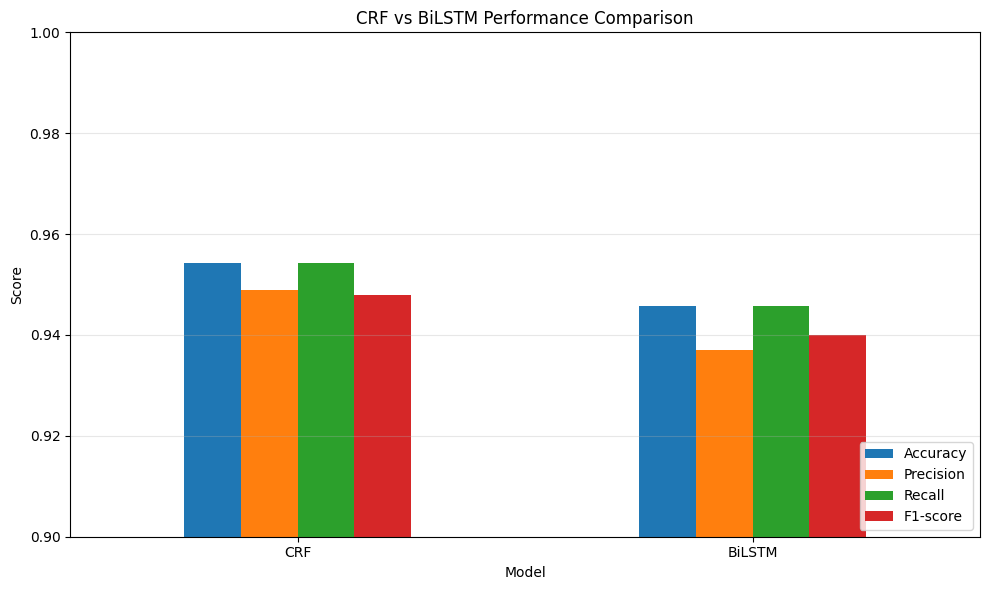

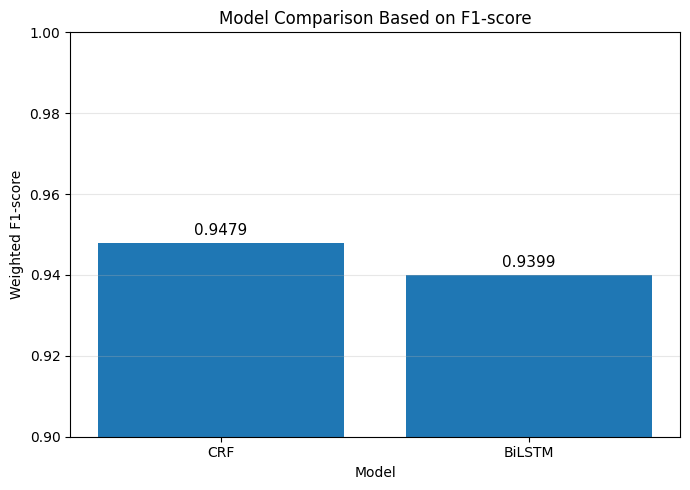

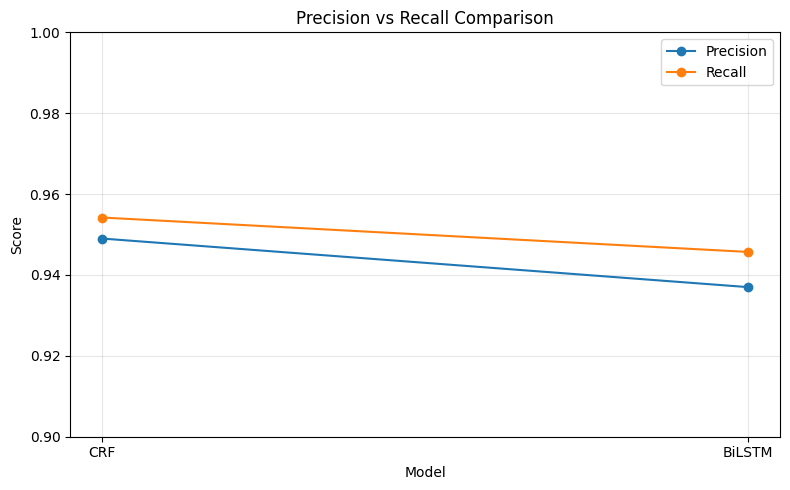

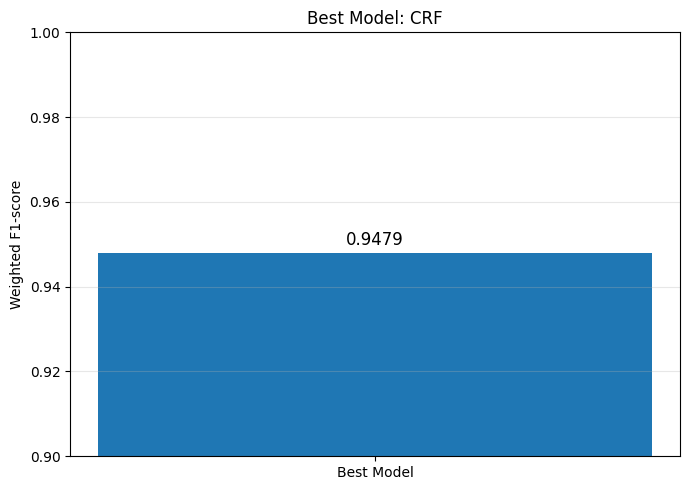

✅ Result plots saved inside results_plots/


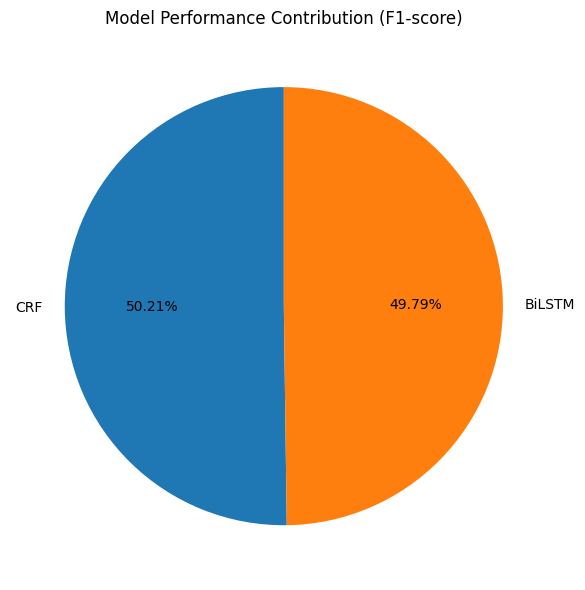

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("results_plots", exist_ok=True)

# Use your real results
results = pd.DataFrame({
    "Model": ["CRF", "BiLSTM"],
    "Accuracy": [0.9542, 0.9457],
    "Precision": [0.9490, 0.9370],
    "Recall": [0.9542, 0.9457],
    "F1-score": [0.9479, 0.9399]
})

display(results)

# =========================
# Plot 1: Overall comparison
# =========================
ax = results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("CRF vs BiLSTM Performance Comparison")
plt.ylabel("Score")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results_plots/model_performance_comparison.png", dpi=300)
plt.show()


# =========================
# Plot 2: F1-score only
# =========================
plt.figure(figsize=(7, 5))
bars = plt.bar(results["Model"], results["F1-score"])

plt.title("Model Comparison Based on F1-score")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.ylim(0.90, 1.00)

for bar, value in zip(bars, results["F1-score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.002,
        f"{value:.4f}",
        ha="center",
        fontsize=11
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results_plots/f1_score_comparison.png", dpi=300)
plt.show()


# =========================
# Plot 3: Precision vs Recall
# =========================
plt.figure(figsize=(8, 5))

plt.plot(results["Model"], results["Precision"], marker="o", label="Precision")
plt.plot(results["Model"], results["Recall"], marker="o", label="Recall")

plt.title("Precision vs Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.90, 1.00)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("results_plots/precision_recall_comparison.png", dpi=300)
plt.show()


# =========================
# Plot 4: Best model decision
# =========================
best_model = results.loc[results["F1-score"].idxmax()]

plt.figure(figsize=(7, 5))
plt.bar(["Best Model"], [best_model["F1-score"]])

plt.title(f"Best Model: {best_model['Model']}")
plt.ylabel("Weighted F1-score")
plt.ylim(0.90, 1.00)
plt.text(0, best_model["F1-score"] + 0.002, f"{best_model['F1-score']:.4f}", ha="center", fontsize=12)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results_plots/best_model.png", dpi=300)
plt.show()

print("✅ Result plots saved inside results_plots/")

import matplotlib.pyplot as plt

# Use your real F1 scores
labels = ["CRF", "BiLSTM"]
f1_scores = [0.9479, 0.9399]

plt.figure(figsize=(6,6))

plt.pie(
    f1_scores,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Model Performance Contribution (F1-score)")
plt.tight_layout()

plt.savefig("results_plots/pie_f1_comparison.png", dpi=300)
plt.show()